# Training Model Deteksi Masker dengan YOLOv8

**Technical Assessment – Data Scientist | Soal 2: Mini Lab**

Notebook ini melatih model YOLOv8 untuk mendeteksi 3 kondisi: `with_mask`, `without_mask`, `incorrectly_worn_mask`.

**Dataset:** [Mask-Detection-YOLOv8](https://universe.roboflow.com/agh-ett2f/mask-detection-yolov8) oleh AGH (Roboflow Universe, lisensi CC BY 4.0)

**Output akhir:** file `best.pt`

## 1. Cek GPU

In [1]:
!nvidia-smi

Thu Jul 16 18:20:11 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2. Install dependency `ultralytics` yaitu library resmi YOLO (v8/v11)

In [2]:
!pip install -q ultralytics==8.3.40 roboflowimport ultralyticsultralytics.checks()

/bin/bash: -c: line 1: syntax error near unexpected token `('
/bin/bash: -c: line 1: `pip install -q ultralytics==8.3.40 roboflowimport ultralyticsultralytics.checks()'


## 3. Unduh dataset dari Roboflow

In [4]:
import sys
!{sys.executable} -m pip install roboflow

from roboflow import Roboflow

API_KEY = "U04hzuJistCGvS1C7Fa8"

rf = Roboflow(api_key=API_KEY)
project = rf.workspace("agh-ett2f").project("mask-detection-yolov8")
dataset = project.version(16).download("yolov8")

print("Dataset tersimpan di:", dataset.location)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 276.9/276.9 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 74.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 134.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 6.5 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 5.0.0.93
    Uninstalling opencv-python-headless-5.0.0.93:
      Successfully uninstalled opencv-python-headless-5.0.0.93
  Attempting uninstall: typer
    Found existing installation: typer 0.26.8
    Uninstalling typer-0.26.8:
      Successfully uninstalled typer-0.26.8
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Mask-Detection-YOLOv8-16 in yolov8:: 100%|██████████| 9106/9106 [00:01<00:00, 7666.04it/s]

Dataset tersimpan di: /content/Mask-Detection-YOLOv8-16


## 4. Inspeksi dataset
Dua hal yang kita cek:
1. **Nama & urutan kelas** harus cocok dengan `PETA_STATUS` di `detect_mask.py`
2. **Jumlah gambar per split**  memastikan train/valid/test tidak kosong

In [5]:
import yaml, os, glob

path_yaml = os.path.join(dataset.location, "data.yaml")

with open(path_yaml) as f:
    cfg = yaml.safe_load(f)

print("Isi data.yaml:")
print(yaml.dump(cfg, sort_keys=False))

for split in ["train", "valid", "test"]:
    folder = os.path.join(dataset.location, split, "images")
    n = len(glob.glob(os.path.join(folder, "*")))
    print(f"{split:6s}: {n:5d} gambar")

Isi data.yaml:
names:
- incorrectly_worn_mask
- with_mask
- without_mask
nc: 3
roboflow:
  license: CC BY 4.0
  project: mask-detection-yolov8
  url: https://universe.roboflow.com/agh-ett2f/mask-detection-yolov8/dataset/16
  version: 16
  workspace: agh-ett2f
test: ../test/images
train: ../train/images
val: ../valid/images

train :  3384 gambar
valid :   593 gambar
test  :   570 gambar


### Distribusi kelas
Object detection sering timpang: kelas `incorrectly_worn_mask` biasanya jauh lebih sedikit.Kalau nanti recall kelas ini rendah, penyebabnya kemungkinan besar di sini — bukan di modelnya.

without_mask            :  7584 objek
with_mask               :  4267 objek
incorrectly_worn_mask   :  3903 objek


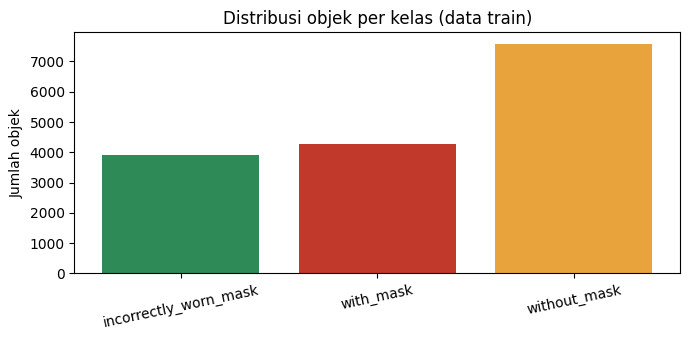

In [6]:
from collections import Counter
import matplotlib.pyplot as plt

hitung = Counter()

for file_label in glob.glob(os.path.join(dataset.location, "train", "labels", "*.txt")):
    with open(file_label) as f:
        for baris in f:
            if baris.strip():
                hitung[cfg["names"][int(baris.split()[0])]] += 1

for kelas, n in hitung.most_common():
    print(f"{kelas:24s}: {n:5d} objek")

plt.figure(figsize=(7, 3.5))
plt.bar(list(hitung.keys()), list(hitung.values()), color=["#2E8B57", "#C0392B", "#E8A33D"])
plt.title("Distribusi objek per kelas (data train)")
plt.ylabel("Jumlah objek")
plt.xticks(rotation=12)
plt.tight_layout()
plt.show()

### Lihat contoh gambar

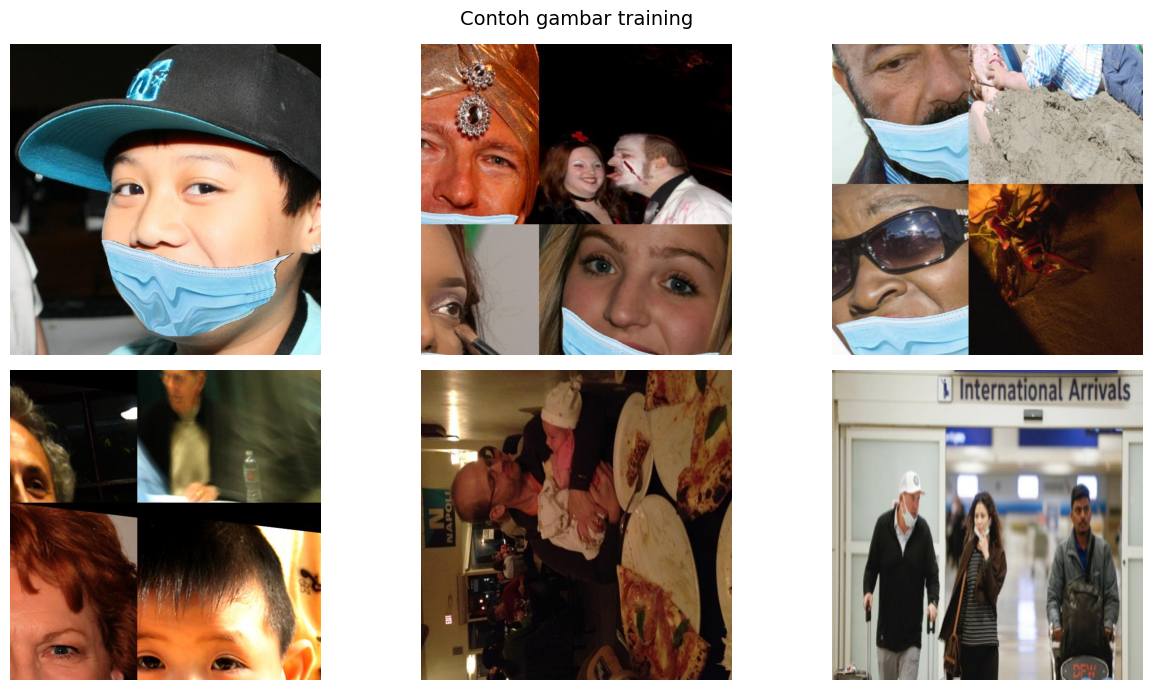

In [7]:
import random
import matplotlib.image as mpimg

contoh = random.sample(glob.glob(os.path.join(dataset.location, "train", "images", "*")), 6)

fig, axes = plt.subplots(2, 3, figsize=(13, 7))

for ax, path in zip(axes.ravel(), contoh):
    ax.imshow(mpimg.imread(path))
    ax.axis("off")

plt.suptitle("Contoh gambar training", fontsize=14)
plt.tight_layout()
plt.show()

## 5. Training
Kita pakai **transfer learning**: mulai dari `yolov8n.pt` yang sudah dilatih di dataset COCO(80 kelas objek umum). Bobot awal itu sudah paham konsep dasar seperti tepi, tekstur,dan bentuk wajah — jadi kita tinggal mengajari lapisan akhir untuk membedakanbermasker vs tidak. Jauh lebih cepat dan akurat daripada melatih dari nol.

**Kenapa `yolov8n` (nano)?** Model paling kecil (~3 juta parameter). Target kita demoreal-time di webcam laptop **tanpa GPU**, jadi kecepatan lebih penting daripadaakurasi maksimal. Kalau laptop punya GPU, ganti ke `yolov8s.pt` untuk akurasi lebih tinggi.

**Parameter penting:**
| Parameter | Nilai | Alasan |
|---|---|---|
| `epochs` | 50 | Cukup untuk konvergensi di dataset ~4.500 gambar |
| `imgsz` | 640 | Resolusi standar YOLO; wajah kecil masih terdeteksi |
| `batch` | 16 | Aman untuk VRAM 16 GB milik T4 || `patience` | 15 | Early stopping — berhenti jika 15 epoch tak ada perbaikan |
| `seed` | 42 | Supaya hasil bisa direproduksi |

In [9]:
!pip install -q ultralytics==8.3.40
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

hasil_training = model.train(
    data=path_yaml,
    epochs=50,
    imgsz=640,
    batch=16,
    patience=15,
    seed=42,
    project="mask_detection",
    name="yolov8n_run",
    plots=True,
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 898.5/898.5 kB 25.1 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


100%|██████████| 6.25M/6.25M [00:00<00:00, 117MB/s]


New https://pypi.org/project/ultralytics/8.4.96 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/content/Mask-Detection-YOLOv8-16/data.yaml, epochs=50, time=None, patience=15, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=mask_detection, name=yolov8n_run, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=42, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, em

100%|██████████| 755k/755k [00:00<00:00, 24.7MB/s]


Overriding model.yaml nc=80 with nc=3

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics

...

      50/50      2.43G     0.9688     0.6205       1.14         39        640: 100%|██████████| 212/212 [00:55<00:00,  3.82it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 19/19 [00:05<00:00,  3.31it/s]

                   all        593       1800      0.921      0.835      0.901      0.615



50 epochs completed in 0.895 hours.
Optimizer stripped from mask_detection/yolov8n_run/weights/last.pt, 6.2MB
Optimizer stripped from mask_detection/yolov8n_run/weights/best.pt, 6.2MB

Validating mask_detection/yolov8n_run/weights/best.pt...
Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 168 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 19/19 [00:06<00:00,  2.85it/s]


                   all        593       1800      0.932      0.836      0.906      0.615
 incorrectly_worn_mask        184        191      0.966      0.895      0.959      0.703
             with_mask        261        951      0.932      0.881      0.935      0.647
          without_mask        249        658      0.899      0.733      0.825      0.496
Speed: 0.2ms preprocess, 2.1ms inference, 0.0ms loss, 2.0ms postprocess per image
Results saved to mask_detection/yolov8n_run


## 6. Evaluasi

`model.val()` menjalankan model pada **data validasi** dan menghitung metrik.

- **Precision** — dari semua yang model bilang "tanpa masker", berapa persen yang benar? Rendah = banyak alarm palsu.
- **Recall** — dari semua orang yang benar-benar tanpa masker, berapa persen yang ketangkap? Rendah = banyak pelanggaran lolos.
- **mAP@50** — rata-rata presisi saat bounding box dianggap benar bila IoU ≥ 50% dengan kotak ground truth. Ini metrik utama object detection.
- **mAP@50-95** — versi lebih ketat: rata-rata mAP di berbagai ambang IoU dari 50% sampai 95%. Mengukur seberapa pas letak kotaknya, bukan cuma apakah objeknya ketangkap.

Untuk use case keselamatan kerja, **recall lebih kita prioritaskan daripada precision**. Alarm palsu biayanya rendah — petugas cek ulang, selesai. Pelanggaran yang lolos biayanya bisa jauh lebih besar.


In [10]:
metrik = model.val()

print(f"\nmAP@50    : {metrik.box.map50:.4f}")
print(f"mAP@50-95 : {metrik.box.map:.4f}")
print(f"Precision : {metrik.box.mp:.4f}")
print(f"Recall    : {metrik.box.mr:.4f}")

print("\nPer kelas:")
for i, nama in enumerate(cfg["names"]):
    print(f"  {nama:24s} mAP@50 = {metrik.box.ap50[i]:.4f}")

Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 168 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs


val: Scanning /content/Mask-Detection-YOLOv8-16/valid/labels.cache... 593 images, 1 backgrounds, 0 corrupt: 100%|██████████| 593/593 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 38/38 [00:13<00:00,  2.74it/s]


                   all        593       1800      0.931      0.837      0.906      0.615
 incorrectly_worn_mask        184        191      0.965      0.895      0.959      0.706
             with_mask        261        951      0.933      0.882      0.933      0.646
          without_mask        249        658      0.895      0.734      0.824      0.495
Speed: 0.4ms preprocess, 5.8ms inference, 0.0ms loss, 4.1ms postprocess per image
Results saved to mask_detection/yolov8n_run2

mAP@50    : 0.9056
mAP@50-95 : 0.6153
Precision : 0.9311
Recall    : 0.8372

Per kelas:
  incorrectly_worn_mask    mAP@50 = 0.9594
  with_mask                mAP@50 = 0.9329
  without_mask             mAP@50 = 0.8244


# Confusion matrix & kurva training
Confusion matrix menunjukkan kelas mana yang tertukar. Kalau `with_mask` sering diprediksi sebagai `incorrectly_worn_mask`, artinya model kesulitan di kasus batas —wajar, karena bedanya memang tipis.Kurva loss: kalau `train loss` terus turun tapi `val loss` naik, itu tanda **overfitting**.


=== confusion_matrix_normalized.png ===


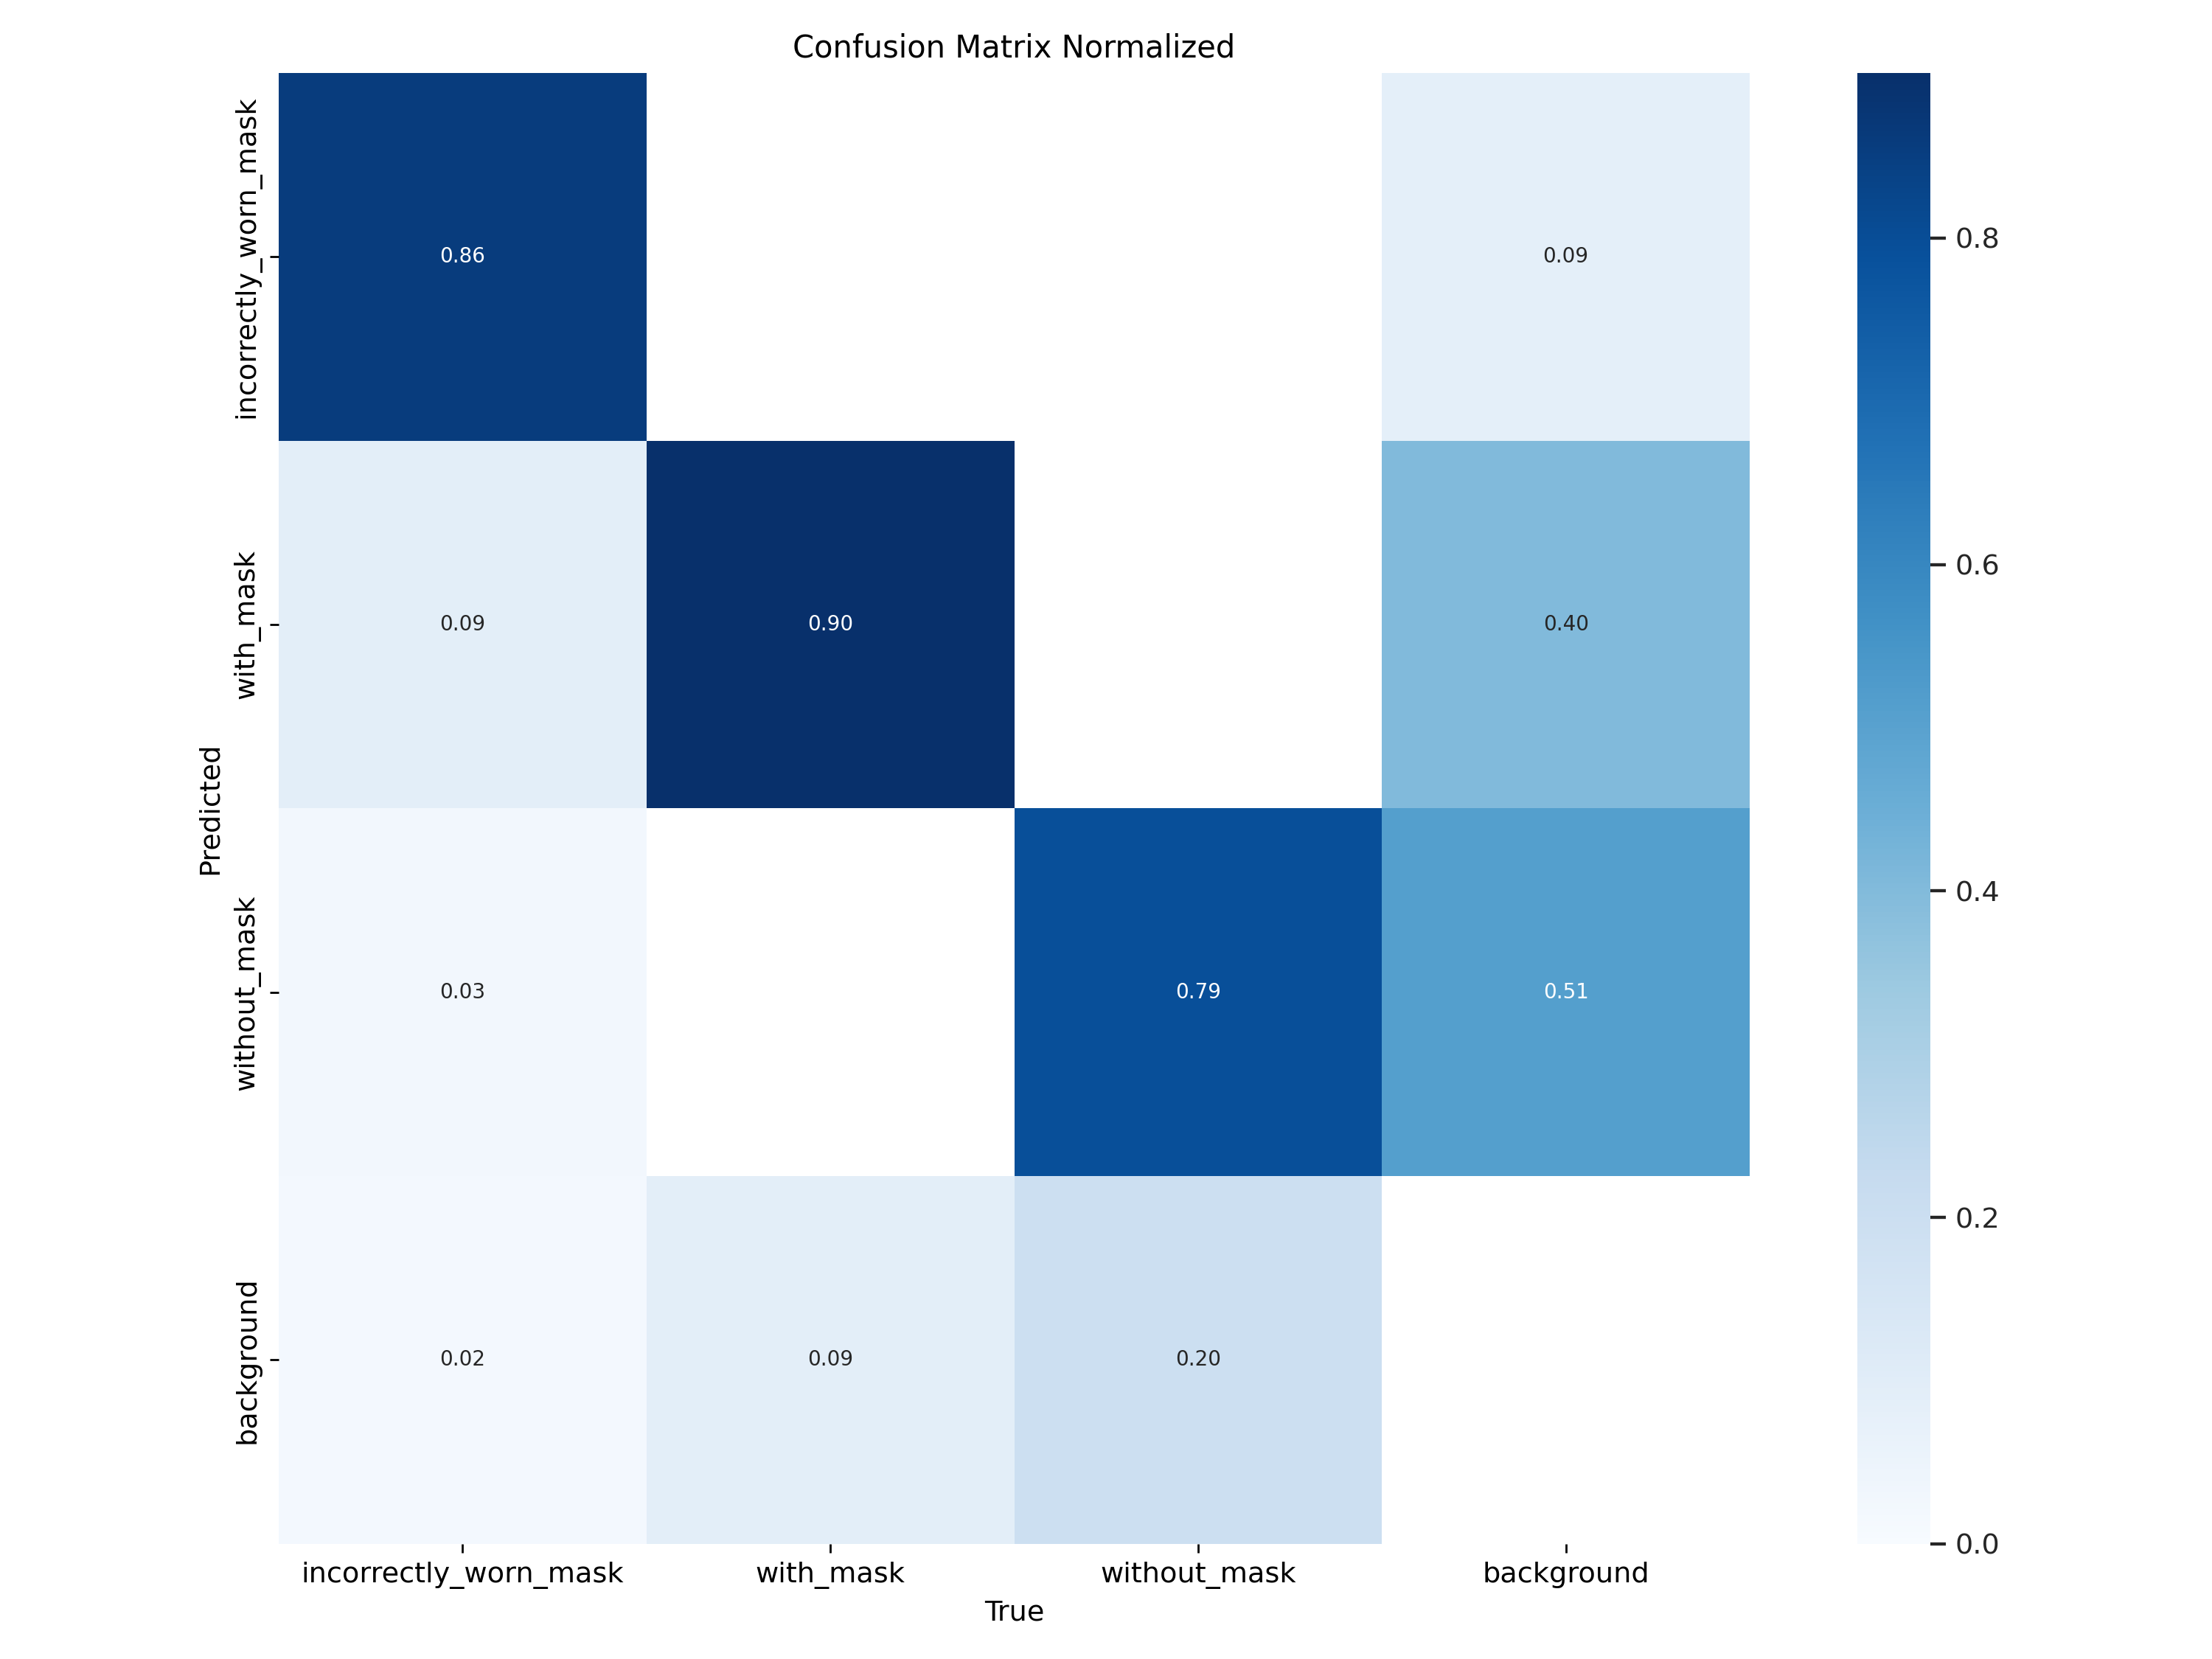


=== results.png ===


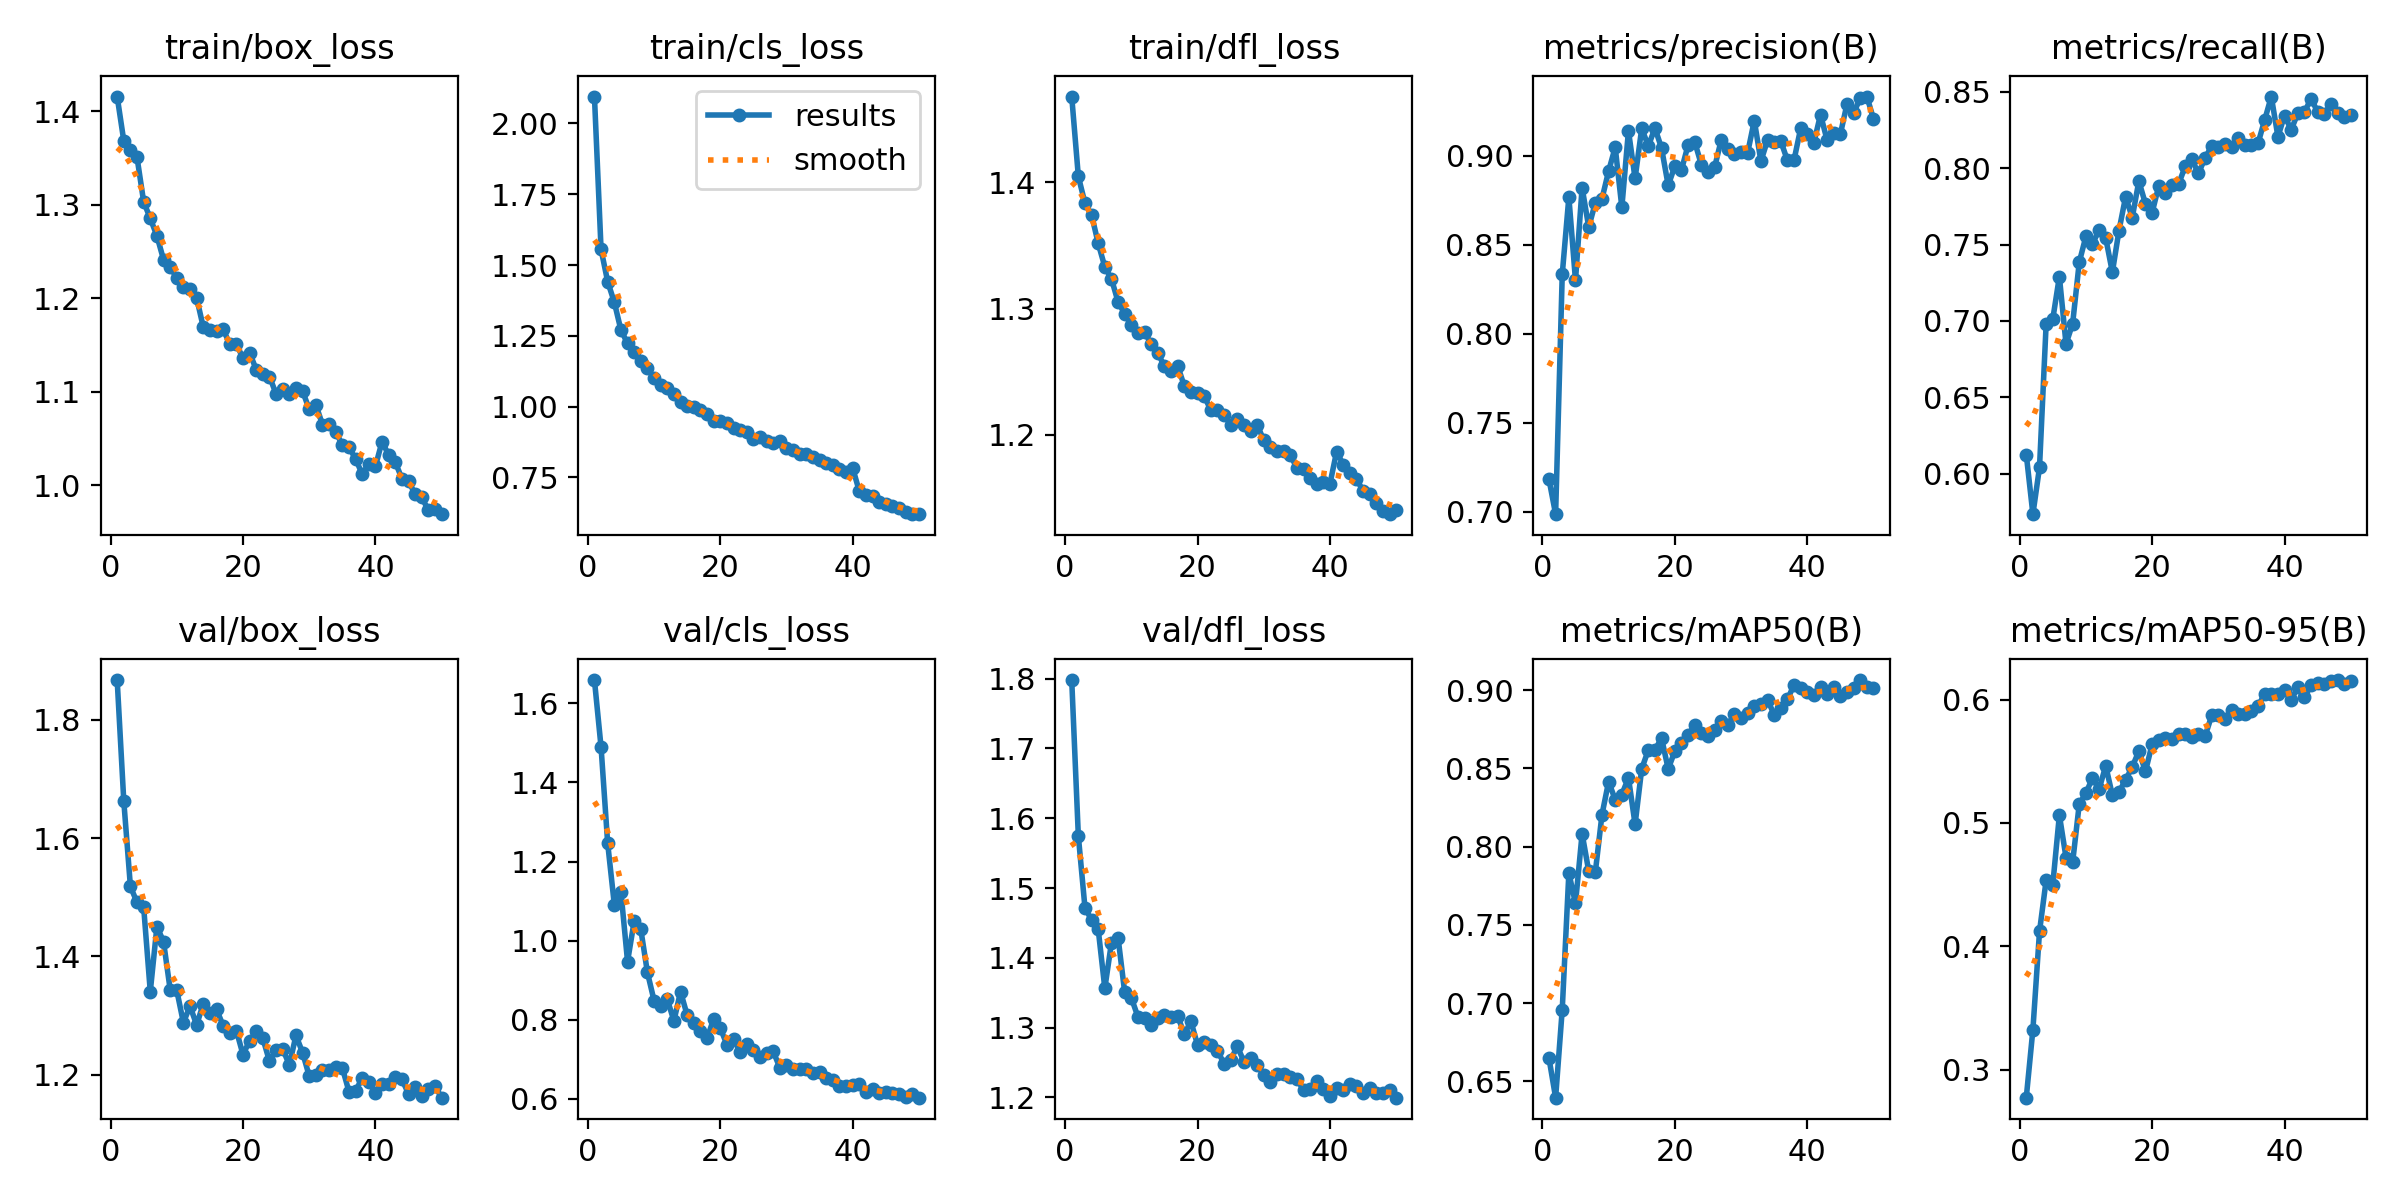


=== val_batch0_pred.jpg ===


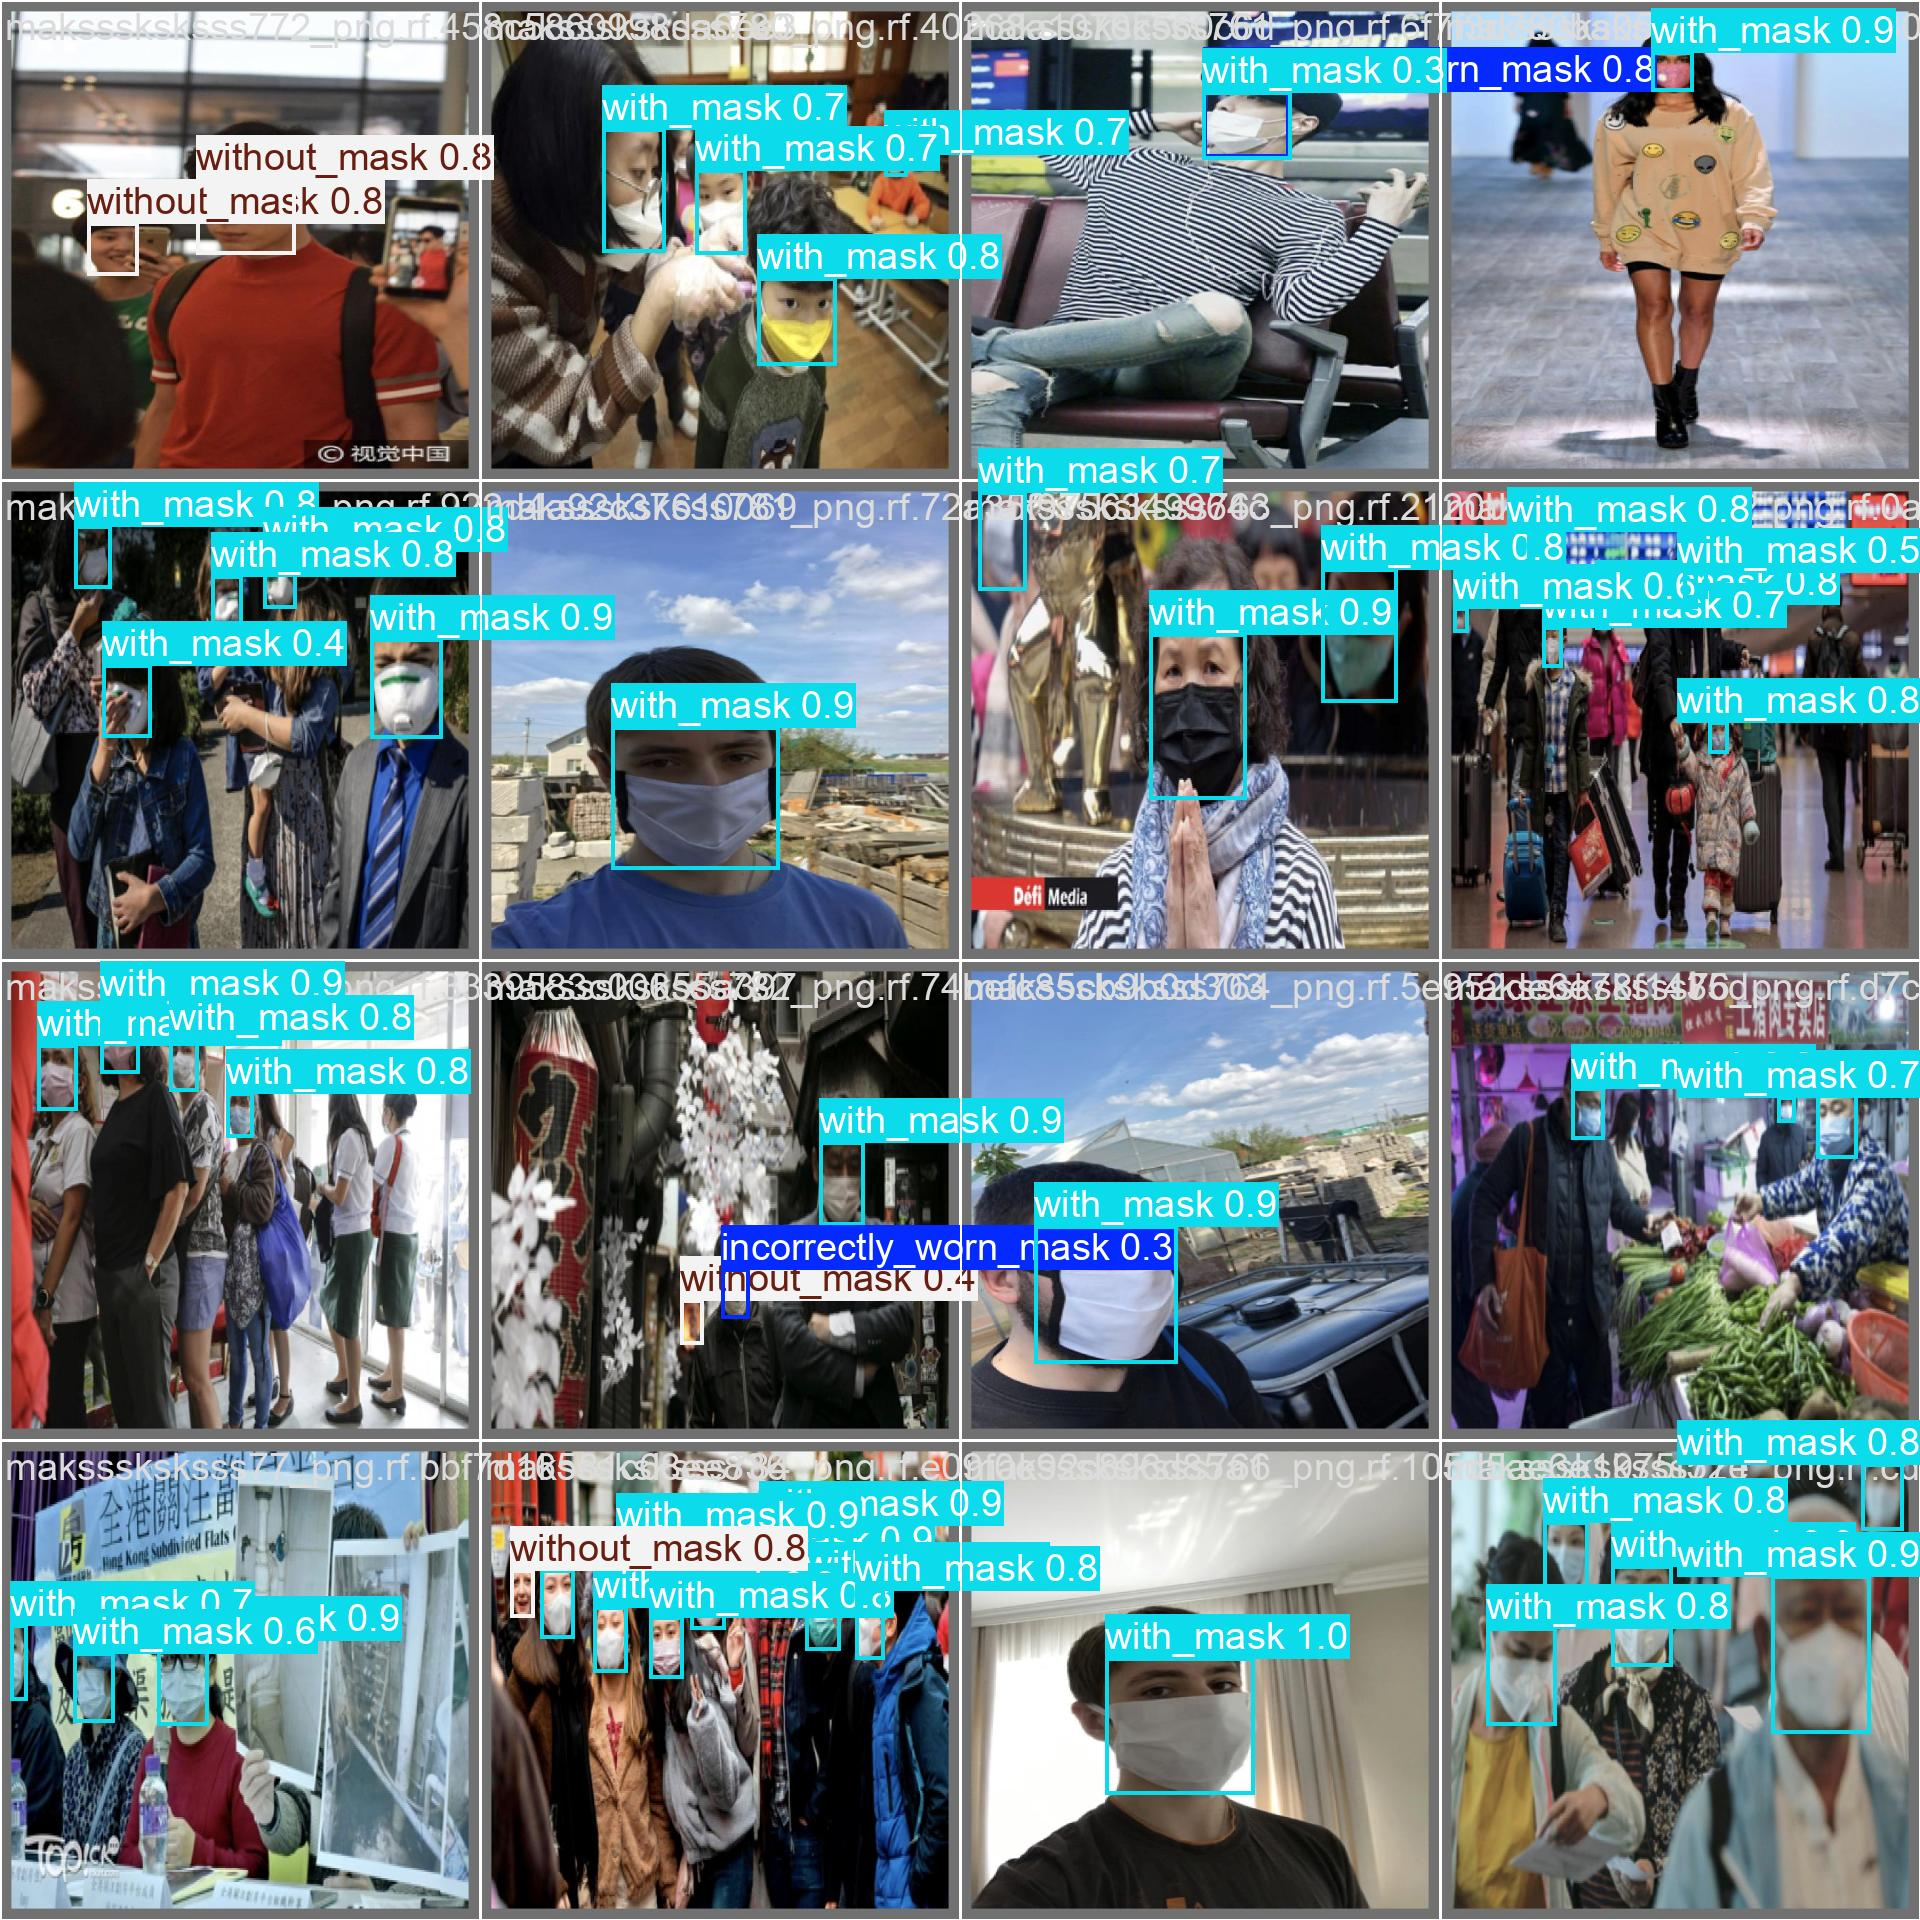

In [11]:
from IPython.display import Image, display

folder_run = "mask_detection/yolov8n_run"

for berkas in ["confusion_matrix_normalized.png", "results.png", "val_batch0_pred.jpg"]:
    path = os.path.join(folder_run, berkas)
    if os.path.exists(path):
        print(f"\n=== {berkas} ===")
        display(Image(filename=path, width=900))

## 7. Uji pada data test
Data test belum pernah dilihat model sama sekali. ini estimasi performa paling jujur.

In [12]:
metrik_test = model.val(split="test")

print(f"\n[TEST] mAP@50 = {metrik_test.box.map50:.4f} | Recall = {metrik_test.box.mr:.4f}")

Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)


val: Scanning /content/Mask-Detection-YOLOv8-16/test/labels... 570 images, 0 backgrounds, 0 corrupt: 100%|██████████| 570/570 [00:00<00:00, 1947.50it/s]


val: New cache created: /content/Mask-Detection-YOLOv8-16/test/labels.cache


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 36/36 [00:08<00:00,  4.16it/s]


                   all        570       2039      0.934      0.805      0.885      0.594
 incorrectly_worn_mask        169        180      0.975      0.877      0.942      0.682
             with_mask        254       1166      0.949      0.825      0.914       0.61
          without_mask        235        693      0.877      0.714      0.798       0.49
Speed: 0.3ms preprocess, 4.0ms inference, 0.0ms loss, 2.5ms postprocess per image
Results saved to mask_detection/yolov8n_run3

[TEST] mAP@50 = 0.8847 | Recall = 0.8054


## 8. Unduh `best.pt`
`best.pt` = bobot dari epoch dengan mAP validasi terbaik (bukan epoch terakhir). File ini yang dipakai `detect_mask.py` di laptop.

In [13]:
from google.colab import files

path_best = os.path.join(folder_run, "weights", "best.pt")

print("Ukuran file:", round(os.path.getsize(path_best) / 1e6, 2), "MB")
files.download(path_best)

Ukuran file: 6.25 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>